In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Seed:", SEED)

Project root: /home/kalpe/projects/adaptive_rl_anomaly_detection
PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda
Seed: 42


In [2]:
PROCESSED_PATH = (
    PROJECT_ROOT / "notebooks" / "datasets" / "processed" / "cicids2017_processed.parquet"
)
assert PROCESSED_PATH.exists(), f"Missing: {PROCESSED_PATH}"

df = pd.read_parquet(PROCESSED_PATH)
print("Dataset shape:", df.shape)
assert "Label" in df.columns

from sklearn.model_selection import train_test_split

X = df.drop(columns=["Label"])
y = (df["Label"] != 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y,
)
X_dev, X_val, y_dev, y_val = train_test_split(
    X_train, y_train, test_size=0.10, random_state=42, stratify=y_train,
)

X_dev = X_dev.reset_index(drop=True)
y_dev = y_dev.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Development:", X_dev.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)
print("\nValidation label counts:")
print(y_val.value_counts().sort_index())

Dataset shape: (2520798, 71)
Development: (1814974, 70)
Validation : (201664, 70)
Test       : (504160, 70)

Validation label counts:
Label
0    167605
1     34059
Name: count, dtype: int64


In [3]:
STATE_S3_PATH = PROJECT_ROOT / "evaluation_results" / "rl_states" / "state_s3.npy"
assert STATE_S3_PATH.exists(), f"Missing: {STATE_S3_PATH}"

state_s3 = np.load(STATE_S3_PATH)
print("S3 shape:", state_s3.shape)
print("S3 dtype:", state_s3.dtype)

assert state_s3.shape[0] == len(y_val), (
    f"S3 rows ({state_s3.shape[0]}) != len(y_val) ({len(y_val)})"
)
assert state_s3.shape[1] == 14

y_val_array = y_val.to_numpy(dtype=np.int64)
uniques, counts = np.unique(y_val_array, return_counts=True)
print("\ny_val unique values:", uniques)
print("y_val counts:", counts)
assert set(uniques.tolist()) <= {0, 1}, f"y_val contains non-binary values: {uniques}"

print("\n[OK] state_s3 row count matches len(y_val), y_val is strictly binary.")

S3 shape: (201664, 14)
S3 dtype: float64

y_val unique values: [0 1]
y_val counts: [167605  34059]

[OK] state_s3 row count matches len(y_val), y_val is strictly binary.


In [4]:
import joblib

MODEL_DIR = PROJECT_ROOT / "notebooks" / "trained_models"
assert MODEL_DIR.exists(), f"Missing: {MODEL_DIR}"

if_models = {
    "isolation_forest": joblib.load(MODEL_DIR / "isolation_forest.joblib"),
    "lof": joblib.load(MODEL_DIR / "local_outlier_factor.joblib"),
    "ocsvm": joblib.load(MODEL_DIR / "one_class_svm.joblib"),
    "autoencoder": joblib.load(MODEL_DIR / "autoencoder.joblib"),
}

for name, model in if_models.items():
    print(f"{name}: {type(model)}")

isolation_forest: <class 'src.models.isolation_forest.IsolationForestModel'>
lof: <class 'src.models.local_outlier_factor.LocalOutlierFactorModel'>
ocsvm: <class 'src.models.one_class_svm.OneClassSVMModel'>
autoencoder: <class 'src.models.autoencoder.AutoEncoderModel'>


In [5]:
ae = if_models["autoencoder"]

print("AutoEncoderModel._device:", ae._device)
print("Actual model parameter device:", next(ae._model.parameters()).device)

AutoEncoderModel._device: cuda
Actual model parameter device: cpu


In [6]:
ae._device = torch.device(DEVICE)
ae._model = ae._model.to(ae._device)

print("AutoEncoderModel._device:", ae._device)
print("Actual model parameter device:", next(ae._model.parameters()).device)

AutoEncoderModel._device: cuda
Actual model parameter device: cuda:0


In [7]:
from src.utils.timer import Timer

dev_scores = {}

with Timer("Isolation Forest — dev scoring"):
    dev_scores["isolation_forest"] = np.asarray(if_models["isolation_forest"].anomaly_score(X_dev))

with Timer("LOF — dev scoring"):
    dev_scores["lof"] = np.asarray(if_models["lof"].anomaly_score(X_dev))

with Timer("OCSVM — dev scoring"):
    dev_scores["ocsvm"] = np.asarray(if_models["ocsvm"].anomaly_score(X_dev))

with Timer("AutoEncoder — dev scoring"):
    dev_scores["autoencoder"] = np.asarray(if_models["autoencoder"].anomaly_score(X_dev))

for name, scores in dev_scores.items():
    print(f"{name:18s}: shape={scores.shape}, min={scores.min():.6f}, max={scores.max():.6f}")

for name, scores in dev_scores.items():
    assert scores.shape == (len(X_dev),)
    assert np.all(np.isfinite(scores))
assert len(y_dev) == len(X_dev)

print("\n[OK] All development detector scores align with X_dev/y_dev.")

2026-08-17 14:12:16 | INFO     | AdaptiveRL | Isolation Forest — dev scoring started.
2026-08-17 14:12:28 | INFO     | AdaptiveRL | Isolation Forest — dev scoring completed in 13.3128 seconds.
2026-08-17 14:12:28 | INFO     | AdaptiveRL | LOF — dev scoring started.
2026-08-17 14:14:33 | INFO     | AdaptiveRL | LOF — dev scoring completed in 128.2541 seconds.
2026-08-17 14:14:33 | INFO     | AdaptiveRL | OCSVM — dev scoring started.
2026-08-17 14:18:22 | INFO     | AdaptiveRL | OCSVM — dev scoring completed in 237.3183 seconds.
2026-08-17 14:18:22 | INFO     | AdaptiveRL | AutoEncoder — dev scoring started.
2026-08-17 14:18:39 | INFO     | AdaptiveRL | AutoEncoder — dev scoring completed in 17.2561 seconds.


isolation_forest  : shape=(1814974,), min=0.319992, max=0.767516
lof               : shape=(1814974,), min=-2.377008, max=418594.157933
ocsvm             : shape=(1814974,), min=-75.389353, max=100.205412
autoencoder       : shape=(1814974,), min=0.000068, max=42782.078125

[OK] All development detector scores align with X_dev/y_dev.


In [8]:
val_scores = {}

with Timer("Isolation Forest — val scoring"):
    val_scores["isolation_forest"] = np.asarray(if_models["isolation_forest"].anomaly_score(X_val))

with Timer("LOF — val scoring"):
    val_scores["lof"] = np.asarray(if_models["lof"].anomaly_score(X_val))

with Timer("OCSVM — val scoring"):
    val_scores["ocsvm"] = np.asarray(if_models["ocsvm"].anomaly_score(X_val))

with Timer("AutoEncoder — val scoring"):
    val_scores["autoencoder"] = np.asarray(if_models["autoencoder"].anomaly_score(X_val))

for name, scores in val_scores.items():
    print(f"{name:18s}: shape={scores.shape}, min={scores.min():.6f}, max={scores.max():.6f}")

for name, scores in val_scores.items():
    assert scores.shape == (len(X_val),)
    assert np.all(np.isfinite(scores))

print("\n[OK] All validation detector scores align with X_val.")

2026-08-17 14:19:24 | INFO     | AdaptiveRL | Isolation Forest — val scoring started.
2026-08-17 14:19:25 | INFO     | AdaptiveRL | Isolation Forest — val scoring completed in 1.3278 seconds.
2026-08-17 14:19:25 | INFO     | AdaptiveRL | LOF — val scoring started.
2026-08-17 14:19:38 | INFO     | AdaptiveRL | LOF — val scoring completed in 13.2041 seconds.
2026-08-17 14:19:38 | INFO     | AdaptiveRL | OCSVM — val scoring started.
2026-08-17 14:20:04 | INFO     | AdaptiveRL | OCSVM — val scoring completed in 26.6575 seconds.
2026-08-17 14:20:04 | INFO     | AdaptiveRL | AutoEncoder — val scoring started.
2026-08-17 14:20:05 | INFO     | AdaptiveRL | AutoEncoder — val scoring completed in 1.6105 seconds.


isolation_forest  : shape=(201664,), min=0.319992, max=0.744344
lof               : shape=(201664,), min=-2.296478, max=8985.527440
ocsvm             : shape=(201664,), min=-73.646861, max=100.205412
autoencoder       : shape=(201664,), min=0.000068, max=2774.155029

[OK] All validation detector scores align with X_val.


In [9]:
from src.rl.state import S3StateBuilder

state_builder = S3StateBuilder()

# Fit score normalizers using the reference validation scores (frozen design: val only)
state_builder.fit_normalizers(val_scores)

# Build the development S3 state
dev_state_s3 = state_builder.build(
    raw_scores=dev_scores,
    traffic_features=X_dev,
)

print("Development S3 shape:", dev_state_s3.shape)
print("dtype:", dev_state_s3.dtype)

# Invariant validations
assert dev_state_s3.shape == (len(X_dev), 14)
assert dev_state_s3.dtype == np.float32
assert np.all(np.isfinite(dev_state_s3))

# Detector-score columns [0:4] must be normalized to [0, 1]
assert np.all(dev_state_s3[:, :4] >= 0.0)
assert np.all(dev_state_s3[:, :4] <= 1.0)

print("\n[OK] Development S3 state is valid and aligned with X_dev.")

Development S3 shape: (1814974, 14)
dtype: float32

[OK] Development S3 state is valid and aligned with X_dev.


In [11]:
from src.rl.action import ActionProjector
from src.rl.environment import AnomalyEnsembleEnv
from src.rl.reward import FINAL_REWARD_SCHEME

# Training environment (dev set, shuffled)
train_env = AnomalyEnsembleEnv(
    states=dev_state_s3,
    y_true=y_dev.to_numpy(dtype=np.int64),
    threshold=0.5,
    action_projector=ActionProjector(method="softmax"),
    reward_scheme=FINAL_REWARD_SCHEME,
    shuffle=True,
    seed=SEED,
)

# Validation environment (precomputed validation state_s3, deterministic/unshuffled)
val_env = AnomalyEnsembleEnv(
    states=state_s3.astype(np.float32),
    y_true=y_val.to_numpy(dtype=np.int64),
    threshold=0.5,
    action_projector=ActionProjector(method="softmax"),
    reward_scheme=FINAL_REWARD_SCHEME,
    shuffle=False,
    seed=SEED,
)

print("Training environment created. Samples:", train_env.n_samples)
print("Validation environment created. Samples:", val_env.n_samples)

assert train_env.n_samples == len(y_dev)
assert val_env.n_samples == len(y_val)
print("\n[OK] Both RL environments initialized with matching sample counts and frozen R1 reward.")

Training environment created. Samples: 1814974
Validation environment created. Samples: 201664

[OK] Both RL environments initialized with matching sample counts and frozen R1 reward.


In [12]:
from src.rl.agent import PPOAgent, PPOConfig
from src.rl.state import STATE_DIM
from src.rl.action import ACTION_DIM

agent_config = PPOConfig(
    state_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    device=DEVICE,
)

agent = PPOAgent(agent_config)
print("PPO Agent created on device:", agent.device)

# 1. Reset environment and sample agent step
state = train_env.reset()
raw_action, log_prob, value = agent.step(state)

print("\n--- Agent Step Verification ---")
print("State shape     :", state.shape)
print("Raw action shape:", raw_action.shape)
print("Raw action      :", raw_action)
print("Log probability :", log_prob)
print("Value estimate  :", value)

assert state.shape == (STATE_DIM,)
assert raw_action.shape == (ACTION_DIM,)
assert np.all(np.isfinite(raw_action))

# 2. Step the environment with the raw action
result = train_env.step(raw_action)

print("\n--- Environment Step Verification ---")
print("Reward          :", result.reward)
print("Done            :", result.done)
print("Ensemble score  :", result.info["ensemble_score"])
print("Projected weights:", result.info["weights"])
print("Weight sum      :", result.info["weights"].sum())
print("True label      :", result.info["y_true"])
print("Prediction      :", result.info["y_pred"])

assert np.isfinite(result.reward)
assert result.info["weights"].shape == (ACTION_DIM,)
assert np.isclose(result.info["weights"].sum(), 1.0, atol=1e-5)
assert np.all(result.info["weights"] >= 0.0)

print("\n[OK] Full cycle verified: state -> agent -> raw action -> softmax projection -> reward.")

PPO Agent created on device: cuda

--- Agent Step Verification ---
State shape     : (14,)
Raw action shape: (4,)
Raw action      : [ 0.198648    2.1633465  -0.17362538  0.8493155 ]
Log probability : -6.405595779418945
Value estimate  : -1.0213124752044678

--- Environment Step Verification ---
Reward          : -1.0
Done            : False
Ensemble score  : 0.4076751172542572
Projected weights: [0.09312073 0.664208   0.06417562 0.17849566]
Weight sum      : 1.0
True label      : 1
Prediction      : 0

[OK] Full cycle verified: state -> agent -> raw action -> softmax projection -> reward.


In [13]:
from pathlib import Path
from src.rl.trainer import Trainer, TrainerConfig

# Define paths for checkpoints and training logs
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "rl"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
TRAINING_LOG_PATH = LOG_DIR / "ppo_training_log.jsonl"

# Remove any old training log file from previous test runs if present
if TRAINING_LOG_PATH.exists():
    TRAINING_LOG_PATH.unlink()

# Configure Trainer for the full training run
# 100,000 timesteps = ~48 updates (with rollout_steps=2048)
trainer_config = TrainerConfig(
    total_timesteps=100_000,
    rollout_steps=agent_config.rollout_steps,
    eval_every_updates=5,
    eval_episodes=1,
    checkpoint_dir=str(CHECKPOINT_DIR),
    checkpoint_every_updates=10,
    log_path=str(TRAINING_LOG_PATH),
    verbose=True,
    seed=SEED,
)

trainer = Trainer(
    agent=agent,
    train_env=train_env,
    val_env=val_env,
    config=trainer_config,
)

print("Trainer initialized successfully.")
print("Checkpoint directory :", CHECKPOINT_DIR)
print("Log path             :", TRAINING_LOG_PATH)
print("Total timesteps      :", trainer_config.total_timesteps)
print("Rollout steps        :", trainer.rollout_steps)
print("Evaluation frequency : Every", trainer_config.eval_every_updates, "updates")
print("Periodic checkpoint  : Every", trainer_config.checkpoint_every_updates, "updates")

Trainer initialized successfully.
Checkpoint directory : /home/kalpe/projects/adaptive_rl_anomaly_detection/checkpoints/rl
Log path             : /home/kalpe/projects/adaptive_rl_anomaly_detection/logs/ppo_training_log.jsonl
Total timesteps      : 100000
Rollout steps        : 2048
Evaluation frequency : Every 5 updates
Periodic checkpoint  : Every 10 updates


In [14]:
from src.utils.timer import Timer

print(f"Starting PPO training for {trainer_config.total_timesteps:,} timesteps...")

with Timer("PPO Training"):
    history = trainer.train()

print(f"\nTraining finished.")
print("Total updates completed:", len(history))
print("Final timesteps         :", trainer._n_timesteps)
print("Best validation reward  :", trainer._best_val_reward)

2026-08-17 14:26:17 | INFO     | AdaptiveRL | PPO Training started.


Starting PPO training for 100,000 timesteps...
[update    1] timesteps=   2048 train_mean_reward=+0.2012 policy_loss=-0.0079 value_loss=4.3881
[update    2] timesteps=   4096 train_mean_reward=+0.2314 policy_loss=-0.0105 value_loss=4.0440
[update    3] timesteps=   6144 train_mean_reward=+0.2705 policy_loss=-0.0101 value_loss=3.4893
[update    4] timesteps=   8192 train_mean_reward=+0.2451 policy_loss=-0.0096 value_loss=3.8529
[update    5] timesteps=  10240 train_mean_reward=+0.2598 policy_loss=-0.0086 value_loss=3.8535 | val_mean_reward=+0.3645 val_f1=0.4445
[update    6] timesteps=  12288 train_mean_reward=+0.2822 policy_loss=-0.0070 value_loss=3.6556
[update    7] timesteps=  14336 train_mean_reward=+0.3711 policy_loss=-0.0068 value_loss=3.7574
[update    8] timesteps=  16384 train_mean_reward=+0.3232 policy_loss=-0.0021 value_loss=3.9787
[update    9] timesteps=  18432 train_mean_reward=+0.3418 policy_loss=-0.0035 value_loss=3.9722
[update   10] timesteps=  20480 train_mean_reward

2026-08-17 14:43:36 | INFO     | AdaptiveRL | PPO Training completed in 1078.3039 seconds.


[update   49] timesteps= 100000 train_mean_reward=+0.5142 policy_loss=-0.0045 value_loss=3.0801

Training finished.
Total updates completed: 49
Final timesteps         : 100000
Best validation reward  : 0.5475940177721358


Saved checkpoints in /home/kalpe/projects/adaptive_rl_anomaly_detection/checkpoints/rl :
  - best.pt         (453.1 KB)
  - update_10.pt    (455.3 KB)
  - update_20.pt    (455.3 KB)
  - update_30.pt    (455.3 KB)
  - update_40.pt    (455.3 KB)


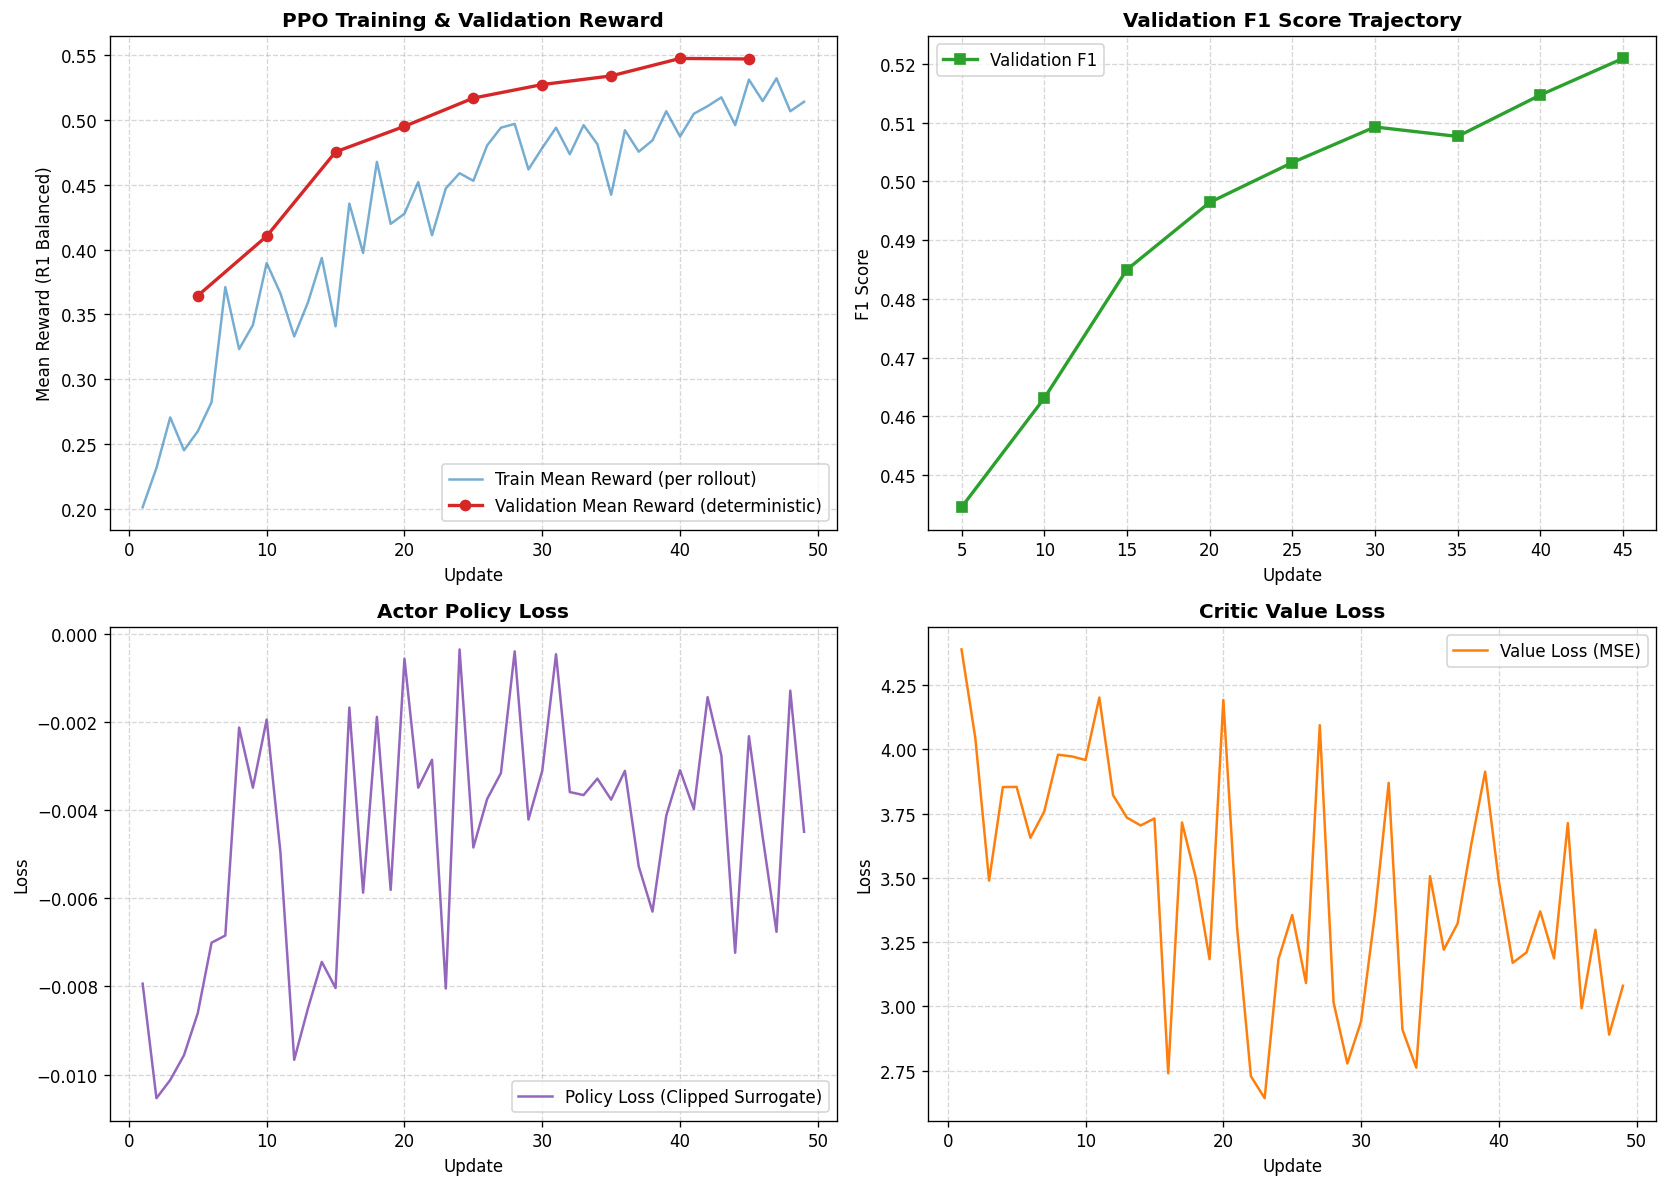


[OK] Best checkpoint confirmed: /home/kalpe/projects/adaptive_rl_anomaly_detection/checkpoints/rl/best.pt
Peak Validation Mean Reward: 0.547594


In [15]:
import json
import matplotlib.pyplot as plt

# 1. Verify saved checkpoints on disk
saved_checkpoints = sorted(CHECKPOINT_DIR.glob("*.pt"))
print("Saved checkpoints in", CHECKPOINT_DIR, ":")
for cp in saved_checkpoints:
    size_kb = cp.stat().st_size / 1024
    print(f"  - {cp.name:15s} ({size_kb:.1f} KB)")

best_checkpoint_path = CHECKPOINT_DIR / "best.pt"
assert best_checkpoint_path.exists(), "best.pt was not saved!"

# 2. Extract metrics from trainer history
updates = [entry["update"] for entry in history]
timesteps = [entry["timesteps"] for entry in history]
train_rewards = [entry["train_mean_reward"] for entry in history]
policy_losses = [entry["policy_loss"] for entry in history]
value_losses = [entry["value_loss"] for entry in history]

val_updates = [entry["update"] for entry in history if "val_mean_reward" in entry]
val_rewards = [entry["val_mean_reward"] for entry in history if "val_mean_reward" in entry]
val_f1s = [entry["val_f1"] for entry in history if "val_f1" in entry]

# 3. Plot PPO Learning Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

# (a) Reward Curve
axes[0, 0].plot(updates, train_rewards, label="Train Mean Reward (per rollout)", color="#1f77b4", alpha=0.6)
axes[0, 0].plot(val_updates, val_rewards, label="Validation Mean Reward (deterministic)", color="#d62728", marker="o", linewidth=2.0)
axes[0, 0].set_title("PPO Training & Validation Reward", fontweight="bold")
axes[0, 0].set_xlabel("Update")
axes[0, 0].set_ylabel("Mean Reward (R1 Balanced)")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)
axes[0, 0].legend()

# (b) Validation F1 Score
axes[0, 1].plot(val_updates, val_f1s, label="Validation F1", color="#2ca02c", marker="s", linewidth=2.0)
axes[0, 1].set_title("Validation F1 Score Trajectory", fontweight="bold")
axes[0, 1].set_xlabel("Update")
axes[0, 1].set_ylabel("F1 Score")
axes[0, 1].grid(True, linestyle="--", alpha=0.5)
axes[0, 1].legend()

# (c) Policy Loss
axes[1, 0].plot(updates, policy_losses, label="Policy Loss (Clipped Surrogate)", color="#9467bd")
axes[1, 0].set_title("Actor Policy Loss", fontweight="bold")
axes[1, 0].set_xlabel("Update")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 0].legend()

# (d) Value Loss
axes[1, 1].plot(updates, value_losses, label="Value Loss (MSE)", color="#ff7f0e")
axes[1, 1].set_title("Critic Value Loss", fontweight="bold")
axes[1, 1].set_xlabel("Update")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\n[OK] Best checkpoint confirmed: {best_checkpoint_path}")
print(f"Peak Validation Mean Reward: {trainer._best_val_reward:.6f}")

In [17]:
import torch
import numpy as np
from src.rl.agent import PPOAgent, PPOConfig
from src.rl.trainer import Trainer, TrainerConfig
from src.rl.state import STATE_DIM
from src.rl.action import ACTION_DIM

# 1. Instantiate fresh agent and load best checkpoint (update 40)
best_checkpoint_path = CHECKPOINT_DIR / "best.pt"
checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)

best_agent_config = PPOConfig(
    state_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    device=DEVICE,
)
best_agent = PPOAgent(best_agent_config)
best_agent.load_state_dict(checkpoint["agent_state"])

print(f"Loaded checkpoint from: {best_checkpoint_path}")
print(f"Checkpoint update count: {checkpoint['n_updates']}")
print(f"Checkpoint timesteps   : {checkpoint['n_timesteps']}")
print(f"Saved best val reward  : {checkpoint['best_val_reward']:.6f}")

# 2. Evaluate best checkpoint agent deterministically on val_env
eval_trainer = Trainer(
    agent=best_agent,
    train_env=train_env,
    val_env=val_env,
    config=TrainerConfig(total_timesteps=1000, rollout_steps=256, eval_every_updates=1),
)

best_val_metrics = eval_trainer.evaluate(val_env, n_episodes=1)

print("\n" + "=" * 60)
print("BEST CHECKPOINT VALIDATION EVALUATION (UPDATE 40)")
print("=" * 60)
print(f"Samples Evaluated : {best_val_metrics['n_steps']}")
print(f"Mean Reward (R1)  : {best_val_metrics['mean_reward']:+.6f}")
print(f"Total Reward      : {best_val_metrics['total_reward']:+.1f}")
print("-" * 60)
print(f"Precision         : {best_val_metrics['precision']:.6f}")
print(f"Recall            : {best_val_metrics['recall']:.6f}")
print(f"F1 Score          : {best_val_metrics['f1']:.6f}")
if "roc_auc" in best_val_metrics:
    print(f"ROC-AUC           : {best_val_metrics['roc_auc']:.6f}")
if "pr_auc" in best_val_metrics:
    print(f"PR-AUC            : {best_val_metrics['pr_auc']:.6f}")
print("-" * 60)
print("Confusion Matrix:")
print(f"  TN: {best_val_metrics['tn']:<8}  FP: {best_val_metrics['fp']:<8}")
print(f"  FN: {best_val_metrics['fn']:<8}  TP: {best_val_metrics['tp']:<8}")
print("=" * 60)

assert best_val_metrics['n_steps'] == len(y_val)
assert np.isclose(best_val_metrics['mean_reward'], checkpoint['best_val_reward'], atol=1e-5)
print("\n[OK] Best checkpoint validation metrics verified and exactly match checkpoint record.")

Loaded checkpoint from: /home/kalpe/projects/adaptive_rl_anomaly_detection/checkpoints/rl/best.pt
Checkpoint update count: 40
Checkpoint timesteps   : 81920
Saved best val reward  : 0.547594

BEST CHECKPOINT VALIDATION EVALUATION (UPDATE 40)
Samples Evaluated : 201664
Mean Reward (R1)  : +0.547594
Total Reward      : +110430.0
------------------------------------------------------------
Precision         : 0.403590
Recall            : 0.710297
F1 Score          : 0.514718
ROC-AUC           : 0.845688
PR-AUC            : 0.548819
------------------------------------------------------------
Confusion Matrix:
  TN: 131855    FP: 35750   
  FN: 9867      TP: 24192   

[OK] Best checkpoint validation metrics verified and exactly match checkpoint record.


In [18]:
import json
import joblib
from pathlib import Path
import pandas as pd

print("=" * 70)
print("PERSISTING TRAINING ARTIFACTS (NOTEBOOK 23)")
print("=" * 70)

EVAL_DIR = PROJECT_ROOT / "evaluation_results"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save fitted S3 percentile normalizer reference distributions
normalizer_state = state_builder.get_normalizer_state()
normalizer_path = EVAL_DIR / "rl_states" / "s3_normalizer_reference.joblib"
normalizer_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(normalizer_state, normalizer_path)
print(f"[OK] S3 Normalizer state saved -> {normalizer_path}")

# 2. Save full training history to CSV and JSON
history_df = pd.DataFrame(history)
history_csv_path = REPORTS_DIR / "ppo_training_history.csv"
history_json_path = REPORTS_DIR / "ppo_training_history.json"
history_df.to_csv(history_csv_path, index=False)
with open(history_json_path, "w") as f:
    json.dump(history, f, indent=4)
print(f"[OK] Training history saved -> {history_csv_path}")

# 3. Save training summary manifest
training_manifest = {
    "project": "Adaptive Reinforcement Learning Anomaly Detection",
    "stage": "PPO Training",
    "device": str(DEVICE),
    "total_timesteps": trainer._n_timesteps,
    "total_updates": trainer._n_updates,
    "best_checkpoint_path": str(CHECKPOINT_DIR / "best.pt"),
    "best_val_mean_reward": float(trainer._best_val_reward),
    "best_val_metrics": best_val_metrics,
}
manifest_path = EVAL_DIR / "training_summary_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(training_manifest, f, indent=4)
print(f"[OK] Training manifest saved -> {manifest_path}")

# 4. Confirm disk files
print("\n--- Verified Training Files ---")
for p in [CHECKPOINT_DIR / "best.pt", normalizer_path, history_csv_path, manifest_path]:
    print(f"✓ {str(p.relative_to(PROJECT_ROOT)):<55} [{(p.stat().st_size/1024):.1f} KB]")

PERSISTING TRAINING ARTIFACTS (NOTEBOOK 23)
[OK] S3 Normalizer state saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/rl_states/s3_normalizer_reference.joblib
[OK] Training history saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/outputs/reports/ppo_training_history.csv
[OK] Training manifest saved -> /home/kalpe/projects/adaptive_rl_anomaly_detection/evaluation_results/training_summary_manifest.json

--- Verified Training Files ---
✓ checkpoints/rl/best.pt                                  [453.1 KB]
✓ evaluation_results/rl_states/s3_normalizer_reference.joblib [6302.4 KB]
✓ outputs/reports/ppo_training_history.csv                [7.5 KB]
✓ evaluation_results/training_summary_manifest.json       [0.7 KB]
